# 08 — Dimensionality Reduction & Manifold Learning
## Machine Learning in SPM Tutorial (Optional)
*RMS AFM & SPM Meeting 2026*

## Goals

- Understand why high-dimensional hyperspectral SPM data is hard to look at directly
- Use **PCA** as a fast *linear* way to compress many channels to 2D
- Use **t-SNE** (and optionally **UMAP**) as *non-linear* methods that pull apart clusters for visualisation
- Colour the 2D embedding by ground-truth domain, by KMeans cluster, and by spatial origin

## Introduction

Hyperspectral SPM data carries a full spectrum at every pixel — easily 64–512 numbers per point. You cannot
eyeball that. **Dimensionality reduction** squashes those many channels down to two so you can plot every pixel
as a dot and *see* the structure. PCA does this linearly (fast, interpretable); t-SNE and UMAP do it non-linearly,
often separating clusters more cleanly at the cost of interpretability and speed. A common, robust recipe is to
run PCA first (say to 20–50 components) and then t-SNE/UMAP on top.

In [1]:
# --- Colab bootstrap: clone the repo & install deps when running on Google Colab ---
import os, sys
if 'google.colab' in sys.modules:
    if not os.path.exists('RMS-AFM-SPM-Meeting-2026'):
        !git clone -q https://github.com/Liambcollins/RMS-AFM-SPM-Meeting-2026.git
    %cd RMS-AFM-SPM-Meeting-2026/notebooks/optional
    print('Colab setup complete.')

In [2]:
import sys, os
sys.path.insert(0, os.path.join('..', '..', 'src'))
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# UMAP is optional (pip install umap-learn). We fall back to t-SNE/PCA if absent.
try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False
    print('umap-learn not installed — the UMAP section will be skipped (t-SNE still runs).')

from viz.plotting import set_style
set_style()
print('Setup complete.')

umap-learn not installed — the UMAP section will be skipped (t-SNE still runs).
Setup complete.


## Section 1 — Generate hyperspectral data and flatten it

Each pixel becomes one high-dimensional sample (its spectrum). The ground-truth domain label comes from the
synthetic abundance maps.

In [3]:
from synthetic.generators import make_hyperspectral_spm

cube, spectra, maps, freq = make_hyperspectral_spm(
    n_x=40, n_y=40, n_freq=128, n_components=4, noise_level=0.25, random_state=1)

n_x, n_y, n_freq = cube.shape
X = cube.reshape(n_x * n_y, n_freq)          # (n_pixels, n_channels)
labels_true = np.argmax(maps, axis=0).ravel()  # ground-truth domain per pixel
rows = np.repeat(np.arange(n_x), n_y)          # spatial (vertical) position

X_scaled = StandardScaler().fit_transform(X)
print(f'{X.shape[0]} pixels  ×  {X.shape[1]} channels  →  reduce to 2D')

1600 pixels  ×  128 channels  →  reduce to 2D


## Section 2 — PCA (linear) vs t-SNE (non-linear)

PCA finds the directions of greatest variance — fast and reversible. t-SNE optimises a 2D layout that keeps
near-neighbours near, which tends to separate clusters visually.

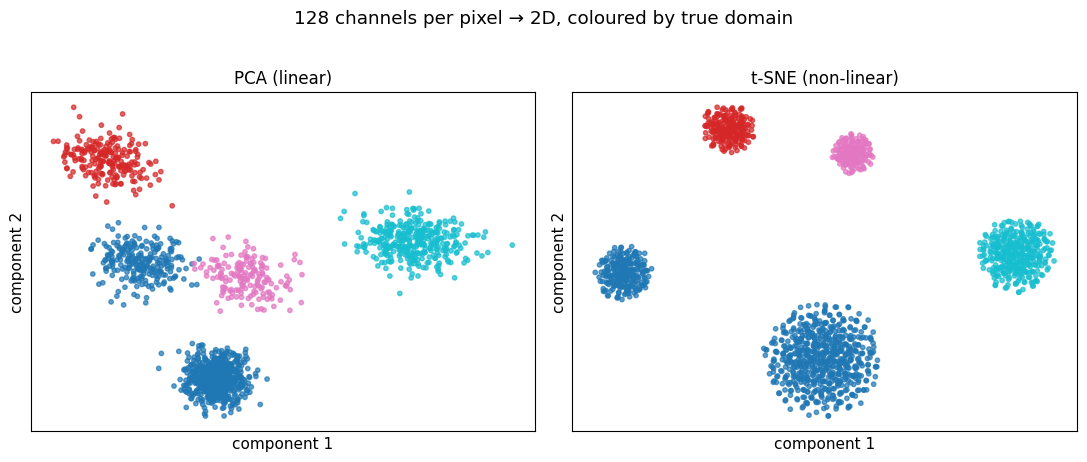

In [4]:
pca2 = PCA(n_components=2, random_state=0).fit_transform(X_scaled)

# PCA-50 first, then t-SNE (standard, faster, less noisy)
pca50 = PCA(n_components=50, random_state=0).fit_transform(X_scaled)
tsne2 = TSNE(n_components=2, perplexity=30, init='pca', random_state=0).fit_transform(pca50)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, emb, title in [(ax[0], pca2, 'PCA (linear)'), (ax[1], tsne2, 't-SNE (non-linear)')]:
    sc = a.scatter(emb[:, 0], emb[:, 1], c=labels_true, cmap='tab10', s=10, alpha=0.7)
    a.set_title(title); a.set_xticks([]); a.set_yticks([])
    a.set_xlabel('component 1'); a.set_ylabel('component 2')
fig.suptitle('128 channels per pixel → 2D, coloured by true domain', y=1.02)
fig.tight_layout(); plt.show()

## Section 3 — What the embedding tells you

Colour the same t-SNE layout three ways: by ground-truth domain, by an *unsupervised* KMeans clustering of the
embedding, and by spatial position. If the unsupervised clusters line up with the true domains, the structure
was real — and recoverable without any labels.

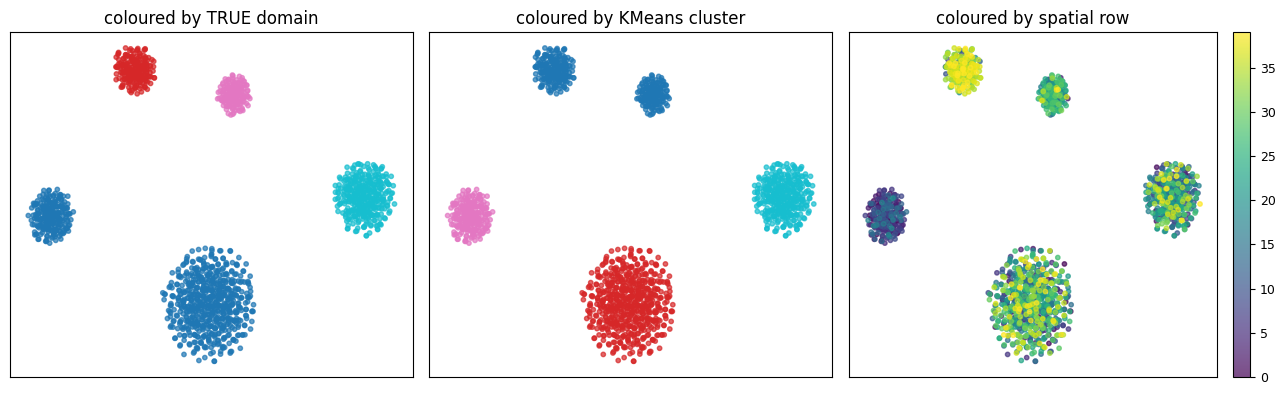

In [5]:
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(tsne2)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].scatter(tsne2[:,0], tsne2[:,1], c=labels_true, cmap='tab10', s=10, alpha=0.7)
ax[0].set_title('coloured by TRUE domain')
ax[1].scatter(tsne2[:,0], tsne2[:,1], c=km, cmap='tab10', s=10, alpha=0.7)
ax[1].set_title('coloured by KMeans cluster')
sc = ax[2].scatter(tsne2[:,0], tsne2[:,1], c=rows, cmap='viridis', s=10, alpha=0.7)
ax[2].set_title('coloured by spatial row')
fig.colorbar(sc, ax=ax[2], fraction=0.046, pad=0.04)
for a in ax: a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()

## Section 4 — UMAP (optional)

UMAP is often faster than t-SNE and preserves more of the global structure. This cell runs only if `umap-learn`
is installed; otherwise it is skipped.

In [6]:
if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0)
    umap2 = reducer.fit_transform(pca50)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.scatter(umap2[:,0], umap2[:,1], c=labels_true, cmap='tab10', s=10, alpha=0.7)
    ax.set_title('UMAP embedding (coloured by true domain)')
    ax.set_xticks([]); ax.set_yticks([]); plt.show()
else:
    print('UMAP not available — skipping. Install with: pip install umap-learn')

UMAP not available — skipping. Install with: pip install umap-learn


## Takeaways

- **Dimensionality reduction lets you SEE high-dimensional SPM data** by compressing many channels to 2D.
- **PCA** is the fast, linear, interpretable baseline; **t-SNE / UMAP** are non-linear and often separate clusters better for *visualisation* (but distances and sizes in the plot are not quantitative).
- **PCA-then-t-SNE/UMAP** is the practical recipe for large datasets.
- If unsupervised clusters in the embedding match known domains, you have found real structure — with no labels.

### Next steps
- Vary t-SNE `perplexity` (5–50) and UMAP `n_neighbors` / `min_dist` and watch the layout change.
- Colour the embedding by a physical quantity (peak position, roughness) instead of a label.